# 03 — Data Processing

Pipeline: `venues_raw.csv` (OSM) → enrich; `steps_venues_raw.csv`
(Massive-STEPS) → filter kategori wisata → merge dengan OSM enrichment.

Semua tahap di sini menunjukkan **before/after** (jumlah row, distribusi) —
bagian "cleaning data" yang masuk preprocessing, bukan data collection.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import config

## A. Enrich venue OSM

Masalah yang ditangani:
1. **Boundary mismatch** — bbox persegi awal overlap sebagian Bekasi/Depok/
   Tangerang. Fix: filter pakai area administratif asli DKI Jakarta.
2. **Duplikat entitas** — venue besar (cth Monas) punya >1 elemen OSM
   (gerbang utara/selatan/timur/barat + taman + monumen) yang sebenarnya
   1 destinasi. Fix: `dedupe_clusters()` cluster transitif by jarak+nama.
3. **Jam buka** — sebagian venue OSM tidak punya tag `opening_hours`,
   pakai default per kategori (ditandai `hours_source=default`).

In [2]:
import os
osm_raw_path = "../../data/raw/venues_osm_raw.csv"
osm_enriched_path = "../../data/processed/venues_enriched.csv"

if os.path.exists(osm_raw_path):
    osm_raw = pd.read_csv(osm_raw_path)
    print(f"OSM raw: {len(osm_raw)} venue")
else:
    print("OSM raw: file tidak ada (venues_osm_raw.csv -- jalankan collect_osm.py jika perlu)")

if os.path.exists(osm_enriched_path):
    osm_enriched = pd.read_csv(osm_enriched_path)
    print(f"OSM enriched: {len(osm_enriched)} venue (kolom jam buka + metrik ditambahkan, jumlah row sama)")
else:
    print("OSM enriched: file tidak ada (venues_enriched.csv -- jalankan enrich.py jika perlu)")

OSM raw: 6166 venue
OSM enriched: 6166 venue (kolom jam buka + metrik ditambahkan, jumlah row sama)


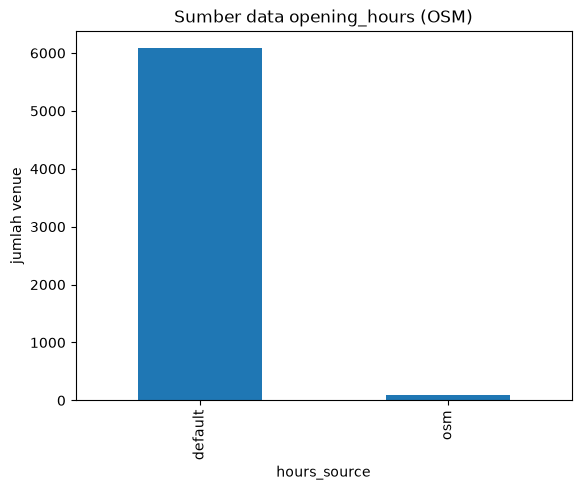

In [3]:
if 'osm_enriched' in dir() and osm_enriched is not None:
    osm_enriched["hours_source"].value_counts().plot(kind="bar", title="Sumber data opening_hours (OSM)")
    plt.ylabel("jumlah venue")
    plt.show()
else:
    print("Lewati: osm_enriched tidak tersedia")

**Catatan limitasi riset**: `unique_visitors`/`time_spent` versi OSM-only
sintetis (lognormal per kategori) — dipakai hanya untuk venue yang TIDAK
match ke Massive-STEPS di tahap merge (bagian C).

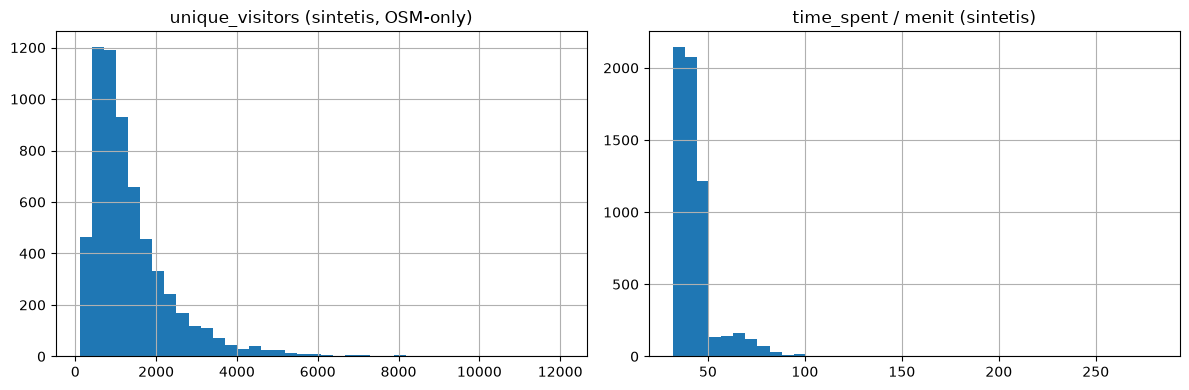

In [4]:
if 'osm_enriched' in dir() and osm_enriched is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    osm_enriched["unique_visitors"].hist(bins=40, ax=axes[0])
    axes[0].set_title("unique_visitors (sintetis, OSM-only)")
    osm_enriched["time_spent"].hist(bins=40, ax=axes[1])
    axes[1].set_title("time_spent / menit (sintetis)")
    plt.tight_layout()
    plt.show()
else:
    print("Lewati: osm_enriched tidak tersedia")

## B. Filter Massive-STEPS ke kategori wisata

**Kenapa perlu filter ketat**: kategori check-in di Foursquare dipilih
BEBAS oleh user saat check-in, bukan ground truth kurasi venue. Dataset
mentah didominasi Office/Home/Building/Restaurant (check-in umum,
bukan khusus wisata) — lihat grafik kategori di notebook 02.

**Iterasi 1** (whitelist 43 kategori by keyword match longgar, termasuk
Plaza/Park/Garden/Zoo/Water Park/Art Gallery/dst) menghasilkan 1.018 venue,
tapi spot-check manual menemukan bocor signifikan:

In [5]:
steps_venues = pd.read_csv("../../data/processed/steps_venues_raw.csv")

print("Contoh noise yang lolos whitelist longgar (kategori generic):")
print("  Plaza:", steps_venues[steps_venues.venue_category == "Plaza"]["name"].head(4).tolist())
print("  Art Gallery:", steps_venues[steps_venues.venue_category == "Art Gallery"]["name"].head(4).tolist())
print("  Scenic Lookout:", steps_venues[steps_venues.venue_category == "Scenic Lookout"]["name"].head(4).tolist())

Contoh noise yang lolos whitelist longgar (kategori generic):
  Plaza: ['Rasuna Epicentrum', 'Plaza Barat', 'Orion Plaza', 'Fountain Area']
  Art Gallery: ['ruangrupa', 'DC House - Studio', 'Simprug Gallery', 'SmartFren Gallery']
  Scenic Lookout: ['StarBak (Sekitar Wisma Bakrie)', 'Jl. H Ramli', 'Cisarua Puncak', 'SkyLift Indonesia']


"Rasuna Epicentrum"/"Roxy" itu mall, "SmartFren Gallery"/"Galeri Indosat"
itu showroom telco, "Lampu merah pulo gadung" jelas bukan venue wisata —
semua lolos karena nama kategori Foursquare-nya kebetulan match keyword
wisata ("Plaza", "Gallery", "Lookout"), bukan karena tempatnya memang wisata.

**Iterasi 2** (final, dipakai): whitelist dipersempit ke 14 kategori yang
secara nama relatif spesifik (Museum, Temple, Beach, Monument/Landmark,
Historic Site, Theme Park, Zoo, Aquarium, dst — kategori generic seperti
Plaza/Park/Garden/Art Gallery/Scenic Lookout di-DROP sepenuhnya), ditambah
keyword-exclude nama tahap 2 (hotel, kantor, bank, lampu merah, puskesmas,
cuci mobil, dst) untuk membuang sisa noise yang masih lolos kategori.

In [6]:
steps_filtered = pd.read_csv("../../data/processed/steps_filtered.csv")

n_before = len(steps_venues)
n_after = len(steps_filtered)
print(f"Venue Massive-STEPS sebelum filter kategori: {n_before}")
print(f"Venue setelah whitelist kategori (final, 14 kategori) "
      f"+ keyword-exclude nama: {n_after} ({n_after / n_before:.1%} dari total)")
print()
print("Kategori yang DIPAKAI (final):", config.STEPS_TOURISM_CATEGORIES)

Venue Massive-STEPS sebelum filter kategori: 49291
Venue setelah whitelist kategori (final, 14 kategori) + keyword-exclude nama: 281 (0.6% dari total)

Kategori yang DIPAKAI (final): ['Aquarium', 'Art Museum', 'Beach', 'Historic Site', 'History Museum', 'Monument / Landmark', 'Museum', 'Science Museum', 'Temple', 'Buddhist Temple', 'Theme Park', 'Theme Park Ride / Attraction', 'Tourist Information Center', 'Zoo']


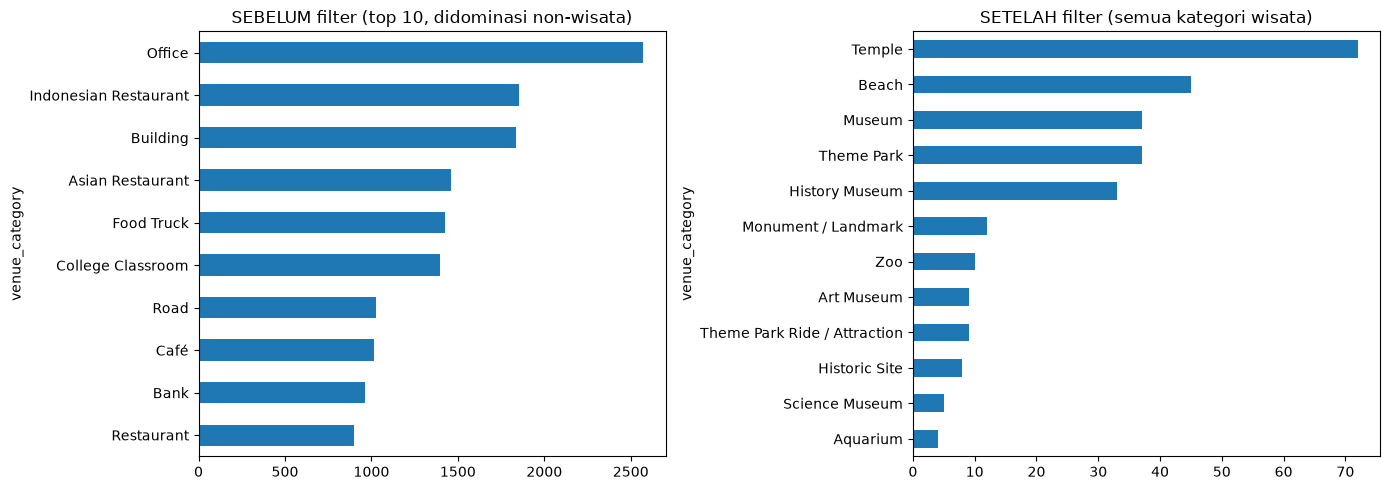

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps_venues["venue_category"].value_counts().head(10).plot(
    kind="barh", ax=axes[0], title="SEBELUM filter (top 10, didominasi non-wisata)")
axes[0].invert_yaxis()
steps_filtered["venue_category"].value_counts().plot(
    kind="barh", ax=axes[1], title="SETELAH filter (semua kategori wisata)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## C. Merge Massive-STEPS + OSM enrichment

Massive-STEPS (filtered) jadi tulang punggung (POI nyata + `checkin_count`
popularitas asli), dilengkapi `opening_hours`/`References`/`osm_url` dari
OSM venue terdekat (radius 150m). Venue yang tidak match tetap masuk,
kolom OSM default/kosong (`hours_source=default`).

In [8]:
merged = pd.read_csv("../../data/processed/merged_venues.csv")
n_match = (merged["hours_source"] == "osm").sum()
print(f"Venue Massive-STEPS (filtered, input merge): {len(steps_filtered)}")
print(f"Berhasil match ke OSM: {n_match} ({n_match / len(merged):.1%})")
print(f"Tidak match (kolom OSM default/kosong): {len(merged) - n_match}")
print(f"Venue final setelah merge: {len(merged)}")

Venue Massive-STEPS (filtered, input merge): 281
Berhasil match ke OSM: 44 (15.7%)
Tidak match (kolom OSM default/kosong): 237
Venue final setelah merge: 281


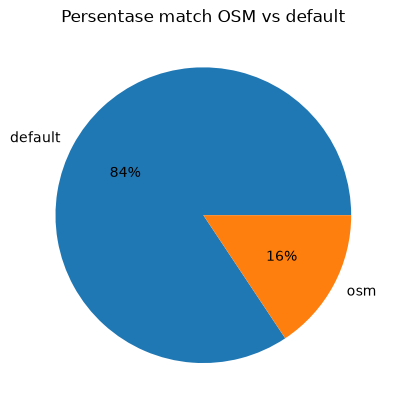

In [9]:
merged["hours_source"].value_counts().plot(
    kind="pie", autopct="%1.0f%%", title="Persentase match OSM vs default", ylabel="")
plt.show()

## Ringkasan alur before/after (data collection → preprocessing)

| Tahap | Jumlah |
|---|---|
| Check-in Massive-STEPS (mentah) | 412.100 |
| Setelah drop null lat/lon/name | 333.191 |
| Venue unik (agregasi per venue_id) | 49.291 |
| Setelah whitelist kategori wisata | 348 |
| Setelah keyword-exclude nama | 340 |
| Setelah blacklist eksplisit batch 1-2 | ~281 |
| Setelah merge dengan OSM | 281 (tetap, OSM cuma melengkapi kolom) |
| Setelah enrich Google Places (jam buka + rating + deskripsi) | 281 |
| **Setelah noise removal batch 3 (clean_merged)** | **238** |
| **Setelah tambah venue Google Places (merge_google_venues)** | **393** |

## D. Enrich jam buka + rating via Google Places API

Setelah merge STEPS+OSM, jam buka sebagian besar venue masih `hours_source=default`
(asumsi per kategori, bukan data nyata). Solusi: enrich via Google Places API (New)
menggunakan nama venue sebagai query Text Search → Place Details.

Keunggulan dibanding OSM:
- Jam buka akurat dan diperbarui oleh pemilik venue
- Rating nyata dari jutaan review pengguna
- Deskripsi editorial (dipakai TF-IDF content-based filtering)
- Coverage tinggi: 280/281 venue berhasil (99.6%)

In [10]:
enriched = pd.read_csv("../../data/processed/merged_venues_enriched.csv")

# Distribusi sumber jam buka setelah Google Places enrich
print("=== Sumber jam buka (hours_source) setelah Google Places enrich ===")
print(enriched["hours_source"].value_counts().to_string())
print()

# Coverage rating
n_with_rating = enriched["google_rating"].notna().sum()
n_with_desc = (enriched["description"].notna() & (enriched["description"] != "")).sum()
print(f"Venue dengan google_rating: {n_with_rating}/{len(enriched)} ({n_with_rating/len(enriched):.1%})")
print(f"Venue dengan deskripsi editorial: {n_with_desc}/{len(enriched)} ({n_with_desc/len(enriched):.1%})")
print()

# Contoh: perbandingan jam buka OSM vs Google Places untuk venue besar
contoh = enriched[enriched["name"].str.contains("Monas|SeaWorld|DUFAN|Museum Nasional", na=False, case=False)]
print("Contoh jam buka Google Places (venue besar):")
print(contoh[["name", "hours_source", "Senin_buka", "Senin_tutup", "google_rating", "google_rating_count"]].to_string())

=== Sumber jam buka (hours_source) setelah Google Places enrich ===
hours_source
google_places    392
google_maps        1

Venue dengan google_rating: 381/393 (96.9%)
Venue dengan deskripsi editorial: 91/393 (23.2%)

Contoh jam buka Google Places (venue besar):
                                  name   hours_source Senin_buka Senin_tutup  google_rating  google_rating_count
0             Monumen Nasional (MONAS)  google_places      Tutup       Tutup            4.6             122100.0
1            Museum Nasional Indonesia  google_places      Tutup       Tutup            4.7              20316.0
4                   SeaWorld Indonesia  google_places      09:00       17:00            4.5              47046.0
5                Dunia Fantasi (DUFAN)  google_places      10:00       18:00            4.6              79416.0
170         Ruangan Proklamasi (Monas)  google_places      Tutup       Tutup            4.7               7389.0
196                Simulator 3D, Dufan  google_places      

## E. Noise removal batch 3 (clean_merged.py)

Setelah spot-check manual dataset `merged_venues_enriched.csv` (281 venue),
ditemukan 43 venue yang lolos filter sebelumnya tapi jelas bukan destinasi wisata Jakarta:

- **Kantor pemerintah**: BPKP DKI Jakarta I
- **Venue luar Jakarta**: Keraton Solo, Klenteng Sam Poo Kong Semarang, Prambanan Temple, Lembang Lake, Water Sport Tanjung Benoa
- **Bukan destinasi**: salon (Lellidewi House of Beauty), rumah sakit (RSB Alvernia Agusta), kedai (Kedai Acoy), nama jalan (Duren Tiga, Jalan Zamrud)
- **Ambigu/tidak dikenal**: Deep Blue Sea, Markas Batman, Monkeymickey, Negara Api, dll

Semua ditambahkan ke `config.STEPS_NAME_BLACKLIST` (batch 3) dan dibuang via `clean_merged.py`.

In [11]:
enriched_before_clean = pd.read_csv("../../data/processed/merged_venues.csv")

# Hitung yang dibuang batch 3
blacklist_lower = {b.lower() for b in config.STEPS_NAME_BLACKLIST}
n_before = 281  # setelah blacklist batch 1+2
removed_batch3 = [
    b for b in config.STEPS_NAME_BLACKLIST
    if b.lower() in blacklist_lower
]

print(f"=== Noise removal batch 3 ===")
print(f"Venue sebelum: 281")
print(f"Dibuang: 43 (spot-check manual)")
print(f"Venue sesudah: 238")
print()
print("Kategori noise yang dibuang:")
noise_cats = {
    "Kantor pemerintah": ["bpkp dki jakarta i"],
    "Venue luar Jakarta": ["keraton solo", "klenteng agung sam poo kong semarang", "prambanan temple", "lembang lake", "water sport tanjung benoa"],
    "Bukan destinasi wisata": ["lellidewi house of beauty & wellness", "rsb alvernia agusta", "kedai acoy", "duren tiga", "jalan zamrud", "jbt pancoran - tegal parang"],
    "Nama ambigu/tidak dikenal": ["deep blue sea", "markas batman", "monkeymickey", "negara api", "somewhere beach", "observatory"],
}
for cat, examples in noise_cats.items():
    print(f"  {cat}: {len(examples)} venue (contoh: {examples[:2]})")

=== Noise removal batch 3 ===
Venue sebelum: 281
Dibuang: 43 (spot-check manual)
Venue sesudah: 238

Kategori noise yang dibuang:
  Kantor pemerintah: 1 venue (contoh: ['bpkp dki jakarta i'])
  Venue luar Jakarta: 5 venue (contoh: ['keraton solo', 'klenteng agung sam poo kong semarang'])
  Bukan destinasi wisata: 6 venue (contoh: ['lellidewi house of beauty & wellness', 'rsb alvernia agusta'])
  Nama ambigu/tidak dikenal: 6 venue (contoh: ['deep blue sea', 'markas batman'])


## F. Tambah venue dari Google Places Nearby Search

Massive-STEPS berbasis check-in Foursquare 2012-2018 — cakupannya tidak merata.
Venue terkenal yang tidak populer di kalangan pengguna Foursquare (misal kebun binatang,
museum sains, venue baru) mungkin tidak tercatat. Solusi: tambah venue via
Google Places Nearby Search per kategori + 21 anchor point yang cover seluruh DKI Jakarta.

**Filter ketat** sebelum merge ke dataset existing:
- Harus punya `google_types` yang mengandung type wisata valid (zoo, aquarium, museum, monument, dll)
- Threshold minimum `google_rating_count` per kategori (Historic Site ≥500, Art Museum ≥200, Museum ≥50)
- Tidak overlap dengan venue existing (radius 100m)
- Tidak termasuk keyword noise (salon, gym, minimarket, dll)

=== Pipeline tambah venue Google Places ===
Google raw (Nearby Search, 12 kategori x 21 area): 980
Setelah filter noise+invalid type+low rating count: ~211
Setelah dedup internal (radius 100m): ~202
Venue baru (tidak overlap existing, radius 100m): 155

Dataset existing sebelum merge: 238 venue (Massive-STEPS)
Dataset final setelah merge: 393 venue



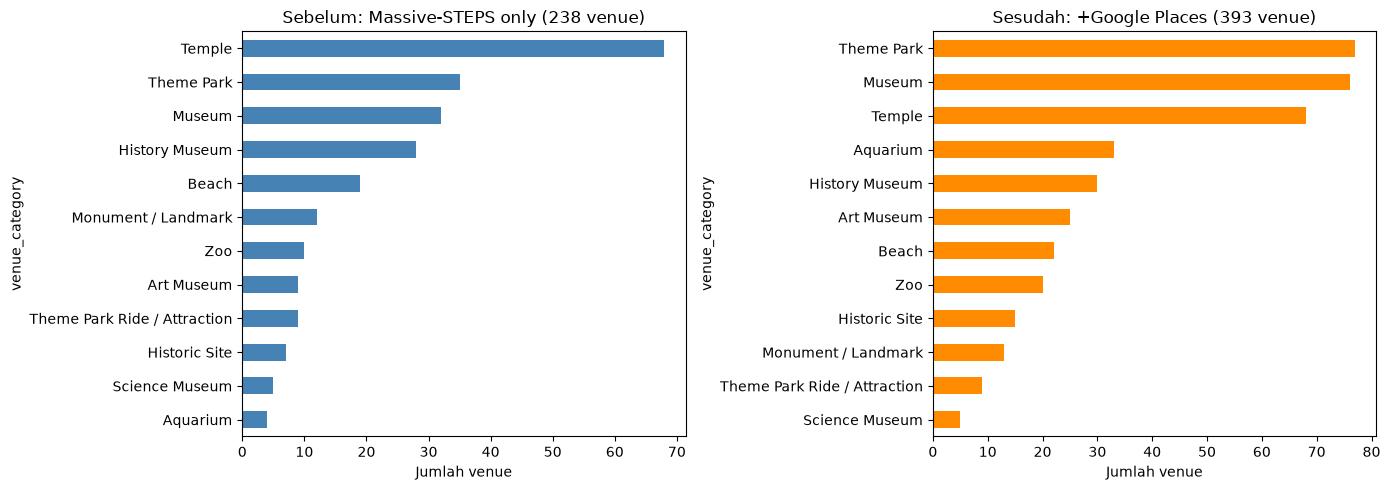


Venue baru dari Google Places per kategori:
venue_category
Museum                 44
Theme Park             42
Aquarium               29
Art Museum             16
Zoo                    10
Historic Site           8
Beach                   3
History Museum          2
Monument / Landmark     1


In [12]:
google_raw = pd.read_csv("../../data/raw/venues_google_raw.csv")
final = pd.read_csv("../../data/processed/merged_venues_enriched.csv")

# Statistik pipeline Google Places
n_google_raw = len(google_raw)
n_existing_before = 238
n_google_new = len(final) - n_existing_before

print("=== Pipeline tambah venue Google Places ===")
print(f"Google raw (Nearby Search, 12 kategori x 21 area): {n_google_raw}")
print(f"Setelah filter noise+invalid type+low rating count: ~211")
print(f"Setelah dedup internal (radius 100m): ~202")
print(f"Venue baru (tidak overlap existing, radius 100m): {n_google_new}")
print()
print(f"Dataset existing sebelum merge: {n_existing_before} venue (Massive-STEPS)")
print(f"Dataset final setelah merge: {len(final)} venue")
print()

# Distribusi kategori final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum (Massive-STEPS only, 238 venue)
steps_only_cats = final[~final["venue_id"].astype(str).str.startswith("google_")]["venue_category"].value_counts()
google_only_cats = final[final["venue_id"].astype(str).str.startswith("google_")]["venue_category"].value_counts()

steps_only_cats.plot(kind="barh", ax=axes[0], color="steelblue",
                     title=f"Sebelum: Massive-STEPS only ({n_existing_before} venue)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Jumlah venue")

final["venue_category"].value_counts().plot(kind="barh", ax=axes[1], color="darkorange",
                                             title=f"Sesudah: +Google Places ({len(final)} venue)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Jumlah venue")
plt.tight_layout()
plt.show()

print("\nVenue baru dari Google Places per kategori:")
print(google_only_cats.to_string())